# Spiking controller with Kalman state estimation

Variant of the integrated-voltage spiking controller in which the controller no
longer uses the raw noisy measurement directly. Instead a Kalman filter (filterpy)
estimates the state x̂ from noisy measurements, using the spike train as the known
control input and the controller drives on x̂. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from filterpy.kalman import KalmanFilter

In [2]:
A = np.array([
    [0.0, 1],            # position rate = 1 * velocity
    [-0.1, -0.1]         # velocity rate = stiffness + damping
])

B = np.array([           # spike-to-force map  
    [0.0, 0.0],
    [2.0, -2.0]          # N1 spikes velocity with +2 and N2 spikes velocity with -2
])


C  = np.diag([20.0, 1.0])      # cost weights: position penalised 20x more than velocity

T = 100                  # total simulated time (s)
dt = 0.01                # output sampling step
t_eval = np.arange(0, T, dt)
f  = 0.1                 # predictive horizon (s)
mu = 0.1                 # spike cost
z_schedule = [(5.0, 5.0), (15.0, 10.0), (30.0, 15.0)]     # (time, target) steps
x0 = [0.0, 0.0]

Af = expm(A * f)
G  = B.T @ Af.T @ C

thresholds = np.zeros(B.shape[1])
# Spike threshold per neuron
for i in range(B.shape[1]):
    thresholds[i] = 0.5 * B[:, i] @ Af.T @ C @ Af @ B[:, i] + mu


F_mat = G @ Af @ (A + np.eye(A.shape[0]))   # how the (predicted) state pulls the drive down
Omega = G @ Af @ B                          # self-reset applied when a neuron spikes


sigma_m = 0.5    # measurement noise
sigma_v = 0.5    # voltage noise
sigma_p = 0.5    # process noise

# low-pass filter the step schedule into a smooth reference z(t)
def get_target(t, z_prev, dt):
    z_base = 0.0
    for t_point, val in z_schedule:
        if t >= t_point:
            z_base = val
    return z_prev + dt * 0.5 * (z_base - z_prev)

In [3]:
N  = B.shape[1]
nT = len(t_eval)

x         = np.zeros((nT, 2))
z         = np.zeros(nT)
V_arr     = np.zeros((nT, N))
s_history = np.zeros((nT, N))

x_hat = np.zeros((nT, 2))
P     = np.zeros((nT, 2, 2)) 
Q = sigma_p**2 * np.eye(2)         # process-noise covariance
R = sigma_m**2 * np.eye(2)         # measurement-noise covariance

K_history = np.zeros((nT, 2, 2))

kf = KalmanFilter(dim_x=2, dim_z=2, dim_u=2)
kf.x = np.array(x0, dtype=float).reshape(2, 1)
kf.P = np.eye(2) * 0.1
kf.Q = Q
kf.R = R
kf.H = np.eye(2)                  # full-state measurement
kf.F = np.eye(2) + dt * A         # discretised plant
kf.B = B                          # spikes enter the filter as the control input

def kalman_update(kf, z_meas):
    if np.allclose(kf.R, 0):
        kf.x = z_meas
        kf.P = np.zeros_like(kf.P)
        kf.K = np.eye(kf.dim_x)
        return
    P_pred = kf.P
    S = kf.H @ P_pred @ kf.H.T + kf.R
    K = P_pred @ kf.H.T @ np.linalg.pinv(S)
    kf.x = kf.x + K @ (z_meas - kf.H @ kf.x)
    I_KH = np.eye(kf.dim_x) - K @ kf.H
    kf.P = I_KH @ P_pred @ I_KH.T + K @ kf.R @ K.T  # Joseph form
    kf.K = K

for i in range(nT - 1):
    z[i+1]     = get_target(t_eval[i], z[i], dt)
    target_vec = np.array([z[i], 0.0])

    z_base_i = 0.0
    for t_point, val in z_schedule:
        if t_eval[i] >= t_point:
            z_base_i = val
    target_dot_vec = np.array([0.5 * (z_base_i - z[i]), 0.0])

    x_measured = x[i] + sigma_m * np.random.standard_normal(N)

    V_current  = V_arr[i]
    difference = V_current - thresholds
    s = np.zeros(N)
    if difference.max() > 0:
        s[np.argmax(difference)] = 1.0
    s_history[i] = s

    
    kf.predict(u=s.reshape(-1, 1))        # predict using the emitted spike
    kalman_update(kf, x_measured.reshape(-1, 1))   # correct with the noisy measurement
    x_hat[i+1]     = kf.x.flatten()       # state estimate used by the controller
    P[i+1]         = kf.P.copy()
    K_history[i+1] = kf.K.copy()
    

    noise_p    = sigma_p * np.random.standard_normal(N) * np.sqrt(dt)
    x[i+1]    = x[i] + dt * (A @ x[i]) + B @ s + noise_p

    # voltage dynamics now driven by the estimate x_hat, not the raw measurement
    V_dot      = (-V_current + G @ (target_dot_vec + target_vec) - F_mat @ x_hat[i]) #New
    V_arr[i+1] = (V_current + dt * V_dot - Omega @ s + sigma_v * np.sqrt(dt) * np.random.standard_normal(N))


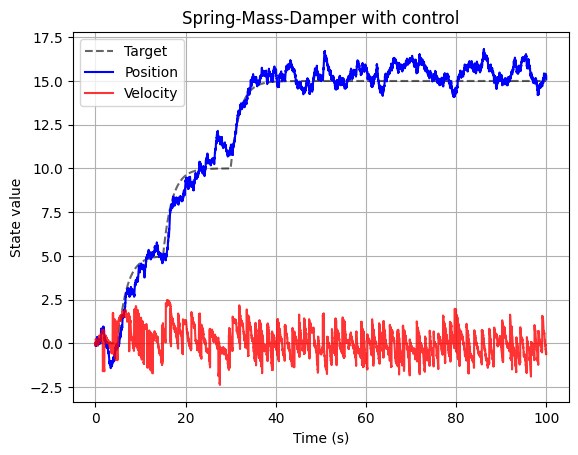

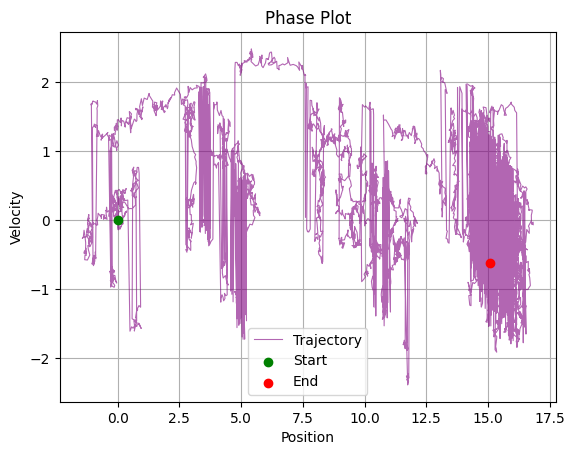

In [4]:
plt.plot(t_eval, z, 'k--', alpha=0.6, label="Target")
plt.plot(t_eval, x[:, 0], color='blue',  label="Position")
plt.plot(t_eval, x[:, 1], color='red', alpha=0.8, label="Velocity")
plt.xlabel("Time (s)")
plt.ylabel("State value")
plt.title("Spring-Mass-Damper with control")
plt.legend()
plt.grid()
plt.show()


plt.figure()
plt.plot(x[:, 0], x[:, 1], color='purple', alpha=0.6, linewidth=0.8, label="Trajectory")
plt.scatter(x[0, 0], x[0, 1], color='green', zorder=5, label="Start")
plt.scatter(x[-1, 0], x[-1, 1], color='red', zorder=5, label="End")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Phase Plot")
plt.legend()
plt.grid()
plt.show()


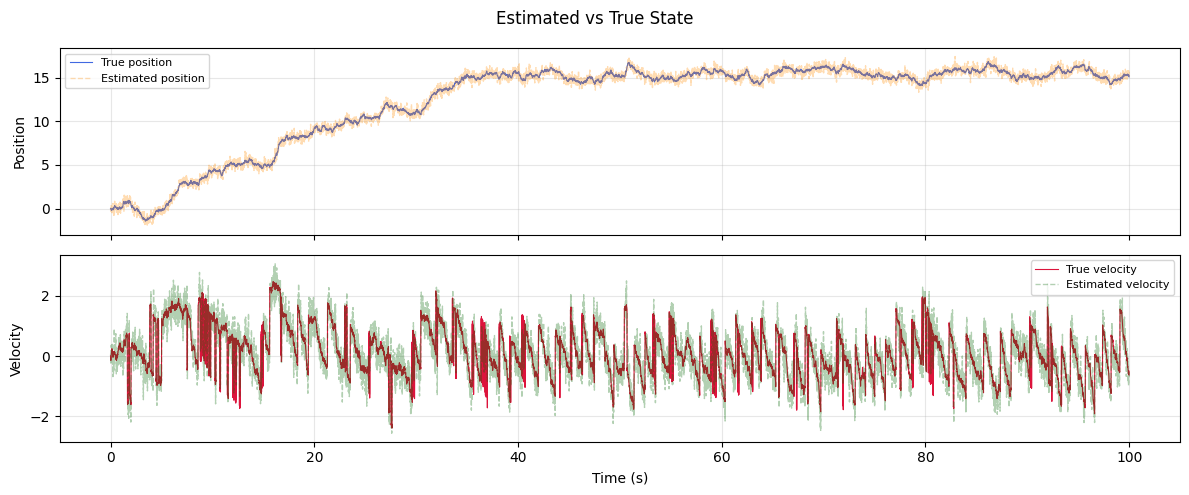

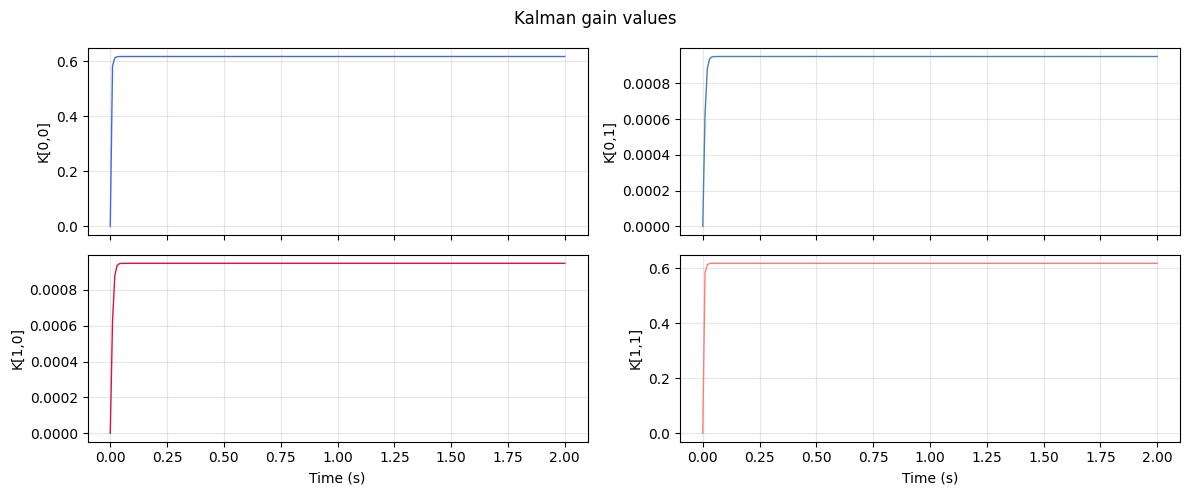

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t_eval, x[:, 0],     color='royalblue', linewidth=0.8,  label='True position')
axes[0].plot(t_eval, x_hat[:, 0], color='darkorange', linewidth=1.0, linestyle='--', alpha=0.3, label='Estimated position')
axes[0].set_ylabel('Position')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(t_eval, x[:, 1],     color='crimson',   linewidth=0.8,  label='True velocity')
axes[1].plot(t_eval, x_hat[:, 1], color='darkgreen', linewidth=1.0, linestyle='--', alpha=0.3, label='Estimated velocity')
axes[1].set_ylabel('Velocity')
axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Estimated vs True State')
plt.tight_layout()
plt.show()

zoom_mask = t_eval <= 2.0

fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)
_labels = [['K[0,0]', 'K[0,1]'], ['K[1,0]', 'K[1,1]']]
_colors = [['royalblue', 'steelblue'], ['crimson', 'salmon']]
for r in range(2):
    for c in range(2):
        axes[r, c].plot(t_eval[zoom_mask], K_history[zoom_mask, r, c],
                        color=_colors[r][c], linewidth=1.0)
        axes[r, c].set_ylabel(_labels[r][c])
        axes[r, c].grid(alpha=0.3)
        if r == 1:
            axes[r, c].set_xlabel('Time (s)')
plt.suptitle('Kalman gain values')
plt.tight_layout()
plt.show()


Total spikes:           484
  Neuron breakdown:     [272 212]
Cumulative error:       54.515
Efficiency ratio:       8.8783 spikes / error-unit


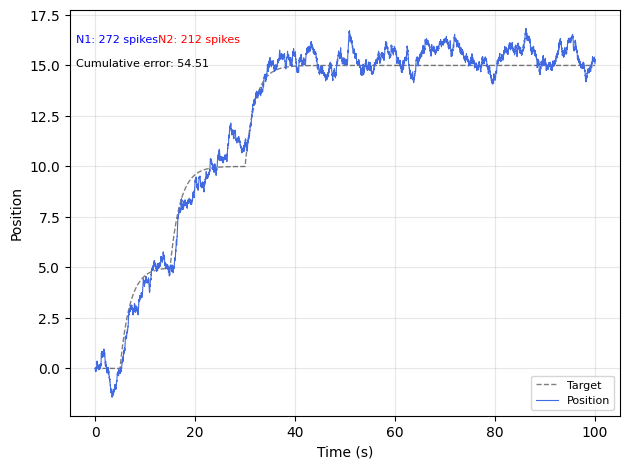

In [6]:
position_error = np.abs(x[:, 0] - z)
cumulative_error = np.cumsum(position_error) * dt

spike_counts = s_history.sum(axis=0).astype(int)
total_spikes = spike_counts.sum()

final_cumulative_error = cumulative_error[-1]
efficiency_ratio = total_spikes / final_cumulative_error

print(f"Total spikes:           {total_spikes}")
print(f"  Neuron breakdown:     {spike_counts}")
print(f"Cumulative error:       {final_cumulative_error:.3f}")
print(f"Efficiency ratio:       {efficiency_ratio:.4f} spikes / error-unit")

plt.plot(t_eval, z, 'k--', alpha=0.5, linewidth=1, label='Target')
plt.plot(t_eval, x[:, 0], color='royalblue', linewidth=0.8, label='Position')

plt.ylabel('Position')
plt.xlabel('Time (s)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

ax = plt.gca()

for j, c in enumerate(spike_counts):
    ax.text(
        0.01 + j * 0.15, 0.92,
        f'N{j+1}: {c} spikes',
        transform=ax.transAxes,
        fontsize=8,
        color=['blue', 'red'][j]
    )

ax.text(
    0.01, 0.86,
    f'Cumulative error: {final_cumulative_error:.2f}',
    transform=ax.transAxes,
    fontsize=8,
    color='black'
)

plt.tight_layout()
plt.show()

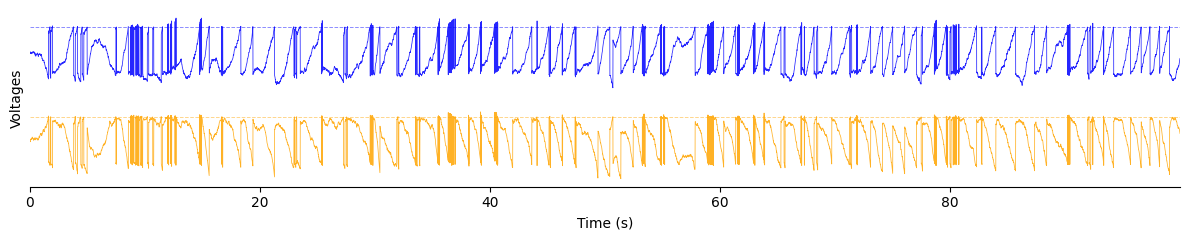

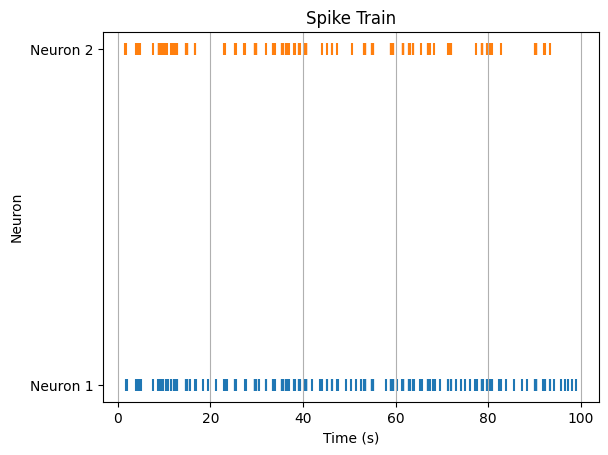

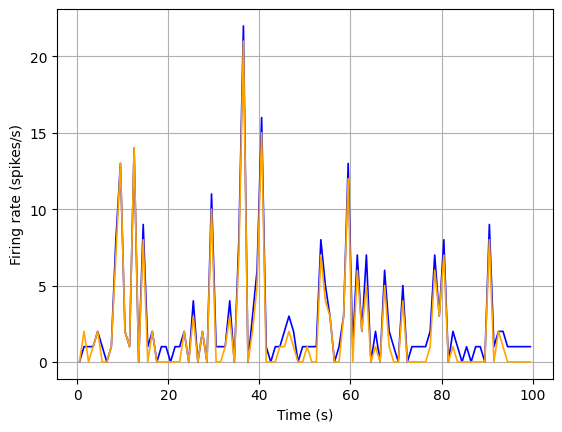

In [7]:
colors = ['blue', 'orange']

gap    = 5
fig, ax = plt.subplots(figsize=(12, 2.5))

for j in range(N):
    v = V_arr[:, j]
    v_norm = (v - np.mean(v)) / (np.std(v) + 1e-9)  
    offset = (N - 1 - j) * gap 
    ax.plot(t_eval, v_norm + offset,
            color=colors[j % len(colors)], linewidth=0.55, alpha=0.85)
    thr_norm = (thresholds[j] - np.mean(v)) / (np.std(v) + 1e-9)
    ax.axhline(thr_norm + offset, color=colors[j % len(colors)],
               linewidth=0.7, linestyle='--', alpha=0.45)

ax.set_yticks([])
ax.set_ylabel('Voltages', fontsize=10)
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_xlim(t_eval[0], t_eval[-1])
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()


plt.figure()
for j in range(N):
    spike_times = t_eval[s_history[:, j] == 1.0]
    plt.scatter(spike_times, np.full_like(spike_times, j + 1),
                marker='|', s=80, label=f"Neuron {j+1}")
plt.xlabel("Time (s)")
plt.ylabel("Neuron")
plt.title("Spike Train")
plt.yticks(range(1, N + 1), [f"Neuron {j+1}" for j in range(N)])
plt.grid(axis='x')
plt.show()

plt.figure()

bins = np.arange(0, T + 1, 1)
bin_centres = bins[:-1] + 1 / 2
for j in range(N):
    spike_times = t_eval[s_history[:, j] == 1.0]
    counts, _ = np.histogram(spike_times, bins=bins)
    plt.plot(bin_centres, counts,
                 color=colors[j], linewidth=1.2, label=f"Neuron {j+1}")
plt.xlabel("Time (s)")
plt.ylabel("Firing rate (spikes/s)")
plt.grid()
plt.show()